# <font color='blue'>PPCA - UnB</font>
# <font color='blue'>Artigo - 1º Semestre 2026</font>

## <font color='blue'>Prestações de Contas Eleitorais de 2024: Uma Análise dos Dados do Tribunal Superior Eleitoral</font>

#### Disciplina: PPCA0028 - Noções Básicas de Seleção de Amostras

#### Professor: Gladston Luiz da Silva

#### Aluno: Adalberto Araujo Aragão

#### Fonte de dados: Portal de Dados Abertos do TSE
 - Dados e Recursos: Extrato bancário
 - Disponível em: https://dadosabertos.tse.jus.br/dataset/prestacao-de-contas-partidarias-2024
 - Acessado em: 09 de abril de 2026

In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python Usada Neste Jupyter Notebook:', python_version())

Versão da Linguagem Python Usada Neste Jupyter Notebook: 3.13.5


In [2]:
# Imports #1
import os
import pyspark
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot
from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession, SQLContext
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.sql.functions import udf
from pyspark.sql.functions import col
import warnings
warnings.filterwarnings("ignore")

In [3]:
print(pyspark.__version__)

4.1.1


In [4]:
!java -version

java version "17.0.12" 2024-07-16 LTS
Java(TM) SE Runtime Environment (build 17.0.12+8-LTS-286)
Java HotSpot(TM) 64-Bit Server VM (build 17.0.12+8-LTS-286, mixed mode, sharing)


In [5]:
print(os.environ.get("JAVA_HOME"))

C:\Program Files\Java\jdk-17


In [6]:
print(os.environ.get("HADOOP_HOME"))

None


In [7]:
# Formatação das saídas
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 400)
from matplotlib.axes._axes import _log as matplotlib_axes_logger
matplotlib_axes_logger.setLevel('ERROR')

In [8]:
# CONFIGURAÇÃO DE REPRODUTIBILIDADE

# Seed global
SEED = 42

# Python
import random

random.seed(SEED)
np.random.seed(SEED)

In [9]:
# Versões dos pacotes usados nesta sessão "jupyter notebook"
%reload_ext watermark
%watermark -a "Adalberto Araujo Aragão" --iversions

Author: Adalberto Araujo Aragão

numpy     : 2.1.3
matplotlib: 3.10.0
pandas    : 2.2.3
seaborn   : 0.13.2
platform  : 1.0.8
pyspark   : 4.1.1



## Preparando o ambiente Spark

In [10]:
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

In [11]:
# Configurar Hadoop no Windows
os.environ["HADOOP_HOME"] = "C:\\hadoop"
os.environ["PATH"] += os.pathsep + "C:\\hadoop\\bin"

In [12]:
spark_session = (
    SparkSession.builder
    .appName("Spark-TSE")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .getOrCreate()
)

In [13]:
# Garantir consistência em shuffle (importante para operações distribuídas)
spark_session.conf.set("spark.sql.shuffle.partitions", "200")

# (Opcional) Evitar variação por paralelismo extremo
spark_session.conf.set("spark.default.parallelism", "200")

In [14]:
sc = spark_session.sparkContext

In [15]:
print(sc)

<SparkContext master=local[*] appName=Spark-TSE>


In [16]:
print(spark_session)

## Carregando e examinando os dados

In [17]:
# Carrega os dados do TSE a partir da sessão Spark
df_spark = spark_session.read.options(delimiter = ";", header = 'true', inferSchema = 'False', encoding = 'iso-8859-1').csv('dados_tse/extrato_bancario_partido_2024.csv')

In [18]:
# Tipo do objeto
type(df_spark)

pyspark.sql.classic.dataframe.DataFrame

In [19]:
# Visualiza os dados
df_spark.show(5)

+----------+----------+-------------+------------+---------+--------------+--------+----------+----------+--------+--------+---------------+-------------+-------------+-------------+-------------+----------------+--------------------+----------------+----------------+------------------------+-----------------------+---------------------+--------------------+--------------------+--------------------+----------------------+--------------------+
|DT_GERACAO|HH_GERACAO|AA_REFERENCIA|  SG_PARTIDO|NM_ESFERA|       NR_CNPJ|CD_BANCO|  NM_BANCO|NR_AGENCIA|NR_CONTA|TP_CONTA|   NR_DOCUMENTO|DT_LANCAMENTO|TP_LANCAMENTO|DS_LANCAMENTO|VR_LANCAMENTO|CD_TIPO_OPERACAO|    DS_TIPO_OPERACAO|CD_FONTE_RECURSO|DS_FONTE_RECURSO|DS_DETALHE_FONTE_RECURSO|NR_CPF_CNPJ_CONTRAPARTE|TP_PESSOA_CONTRAPARTE|      NM_CONTRAPARTE|CD_BANCO_CONTRAPARTE|NM_BANCO_CONTRAPARTE|NR_AGENCIA_CONTRAPARTE|NR_CONTA_CONTRAPARTE|
+----------+----------+-------------+------------+---------+--------------+--------+----------+----------+

## Verificando e limpando os dados ("VR_LANCAMENTO")

In [20]:
# Visualiza os metadados (schema)
df_spark.printSchema()

root
 |-- DT_GERACAO: string (nullable = true)
 |-- HH_GERACAO: string (nullable = true)
 |-- AA_REFERENCIA: string (nullable = true)
 |-- SG_PARTIDO: string (nullable = true)
 |-- NM_ESFERA: string (nullable = true)
 |-- NR_CNPJ: string (nullable = true)
 |-- CD_BANCO: string (nullable = true)
 |-- NM_BANCO: string (nullable = true)
 |-- NR_AGENCIA: string (nullable = true)
 |-- NR_CONTA: string (nullable = true)
 |-- TP_CONTA: string (nullable = true)
 |-- NR_DOCUMENTO: string (nullable = true)
 |-- DT_LANCAMENTO: string (nullable = true)
 |-- TP_LANCAMENTO: string (nullable = true)
 |-- DS_LANCAMENTO: string (nullable = true)
 |-- VR_LANCAMENTO: string (nullable = true)
 |-- CD_TIPO_OPERACAO: string (nullable = true)
 |-- DS_TIPO_OPERACAO: string (nullable = true)
 |-- CD_FONTE_RECURSO: string (nullable = true)
 |-- DS_FONTE_RECURSO: string (nullable = true)
 |-- DS_DETALHE_FONTE_RECURSO: string (nullable = true)
 |-- NR_CPF_CNPJ_CONTRAPARTE: string (nullable = true)
 |-- TP_PESSOA_

In [21]:
# Visualiza valores ausentes
df_spark.select([count(when(col(c).isNull(), c)).alias(c) for c in df_spark.columns]).show()

+----------+----------+-------------+----------+---------+-------+--------+--------+----------+--------+--------+------------+-------------+-------------+-------------+-------------+----------------+----------------+----------------+----------------+------------------------+-----------------------+---------------------+--------------+--------------------+--------------------+----------------------+--------------------+
|DT_GERACAO|HH_GERACAO|AA_REFERENCIA|SG_PARTIDO|NM_ESFERA|NR_CNPJ|CD_BANCO|NM_BANCO|NR_AGENCIA|NR_CONTA|TP_CONTA|NR_DOCUMENTO|DT_LANCAMENTO|TP_LANCAMENTO|DS_LANCAMENTO|VR_LANCAMENTO|CD_TIPO_OPERACAO|DS_TIPO_OPERACAO|CD_FONTE_RECURSO|DS_FONTE_RECURSO|DS_DETALHE_FONTE_RECURSO|NR_CPF_CNPJ_CONTRAPARTE|TP_PESSOA_CONTRAPARTE|NM_CONTRAPARTE|CD_BANCO_CONTRAPARTE|NM_BANCO_CONTRAPARTE|NR_AGENCIA_CONTRAPARTE|NR_CONTA_CONTRAPARTE|
+----------+----------+-------------+----------+---------+-------+--------+--------+----------+--------+--------+------------+-------------+-------------+

In [18]:
# Definir o dataset ANTES do tratamento
n_antes = df_spark.count()

print(n_antes)

1197344


In [18]:
# Tratar valores inconsistentes. Substituir '#NULO' e '#NE' por 'None'
from pyspark.sql.functions import when

df_spark = df_spark.replace(['#NULO#', '#NULO', '#NE'], None)

In [19]:
from pyspark.sql.functions import col, regexp_replace

# Substituir vírgulas por pontos e transformá-los em numéricos
df_spark = df_spark.withColumn(
    "VR_LANCAMENTO",
    regexp_replace(col("VR_LANCAMENTO"), ",", ".").cast("double")
)

In [21]:
# Definir a contagem para valores ausentes
n_nulos_valor = df_spark.filter(col("VR_LANCAMENTO").isNull()).count()

print(n_nulos_valor)

0


In [22]:
# Excluir valores ausentes
df_spark = df_spark.na.drop(subset=["VR_LANCAMENTO"])

In [23]:
# Definir o dataset DEPOIS do tratamento
n_depois = df_spark.count()

print(n_depois)

1197344


In [24]:
# Resulado
print(n_antes, n_nulos_valor, n_depois)

1197344 0 1197344


In [25]:
# Verificar valores "zero" (nulos)
df_spark.filter(col("VR_LANCAMENTO") == 0).count()

15

In [26]:
# Validar valores negativos
df_spark.filter(col("VR_LANCAMENTO") < 0).count()

0

In [31]:
# Obter o resumo estatístico da variável de interesse
resumo_estatistico = df_spark.select("VR_LANCAMENTO").describe().show()

+-------+------------------+
|summary|     VR_LANCAMENTO|
+-------+------------------+
|  count|           1197344|
|   mean|29978.394858286505|
| stddev|2051300.6450649356|
|    min|               0.0|
|    max|    8.8683948785E8|
+-------+------------------+



In [32]:
# Selecionar a coluna "VR_LANCAMENTO" e convertê-la para Pandas
df_pandas = df_spark.select("VR_LANCAMENTO").toPandas()

df_valor = df_pandas.dropna()

In [33]:
# Mediana (2º Quartil)
mediana = df_valor['VR_LANCAMENTO'].median()
print(mediana)

250.0


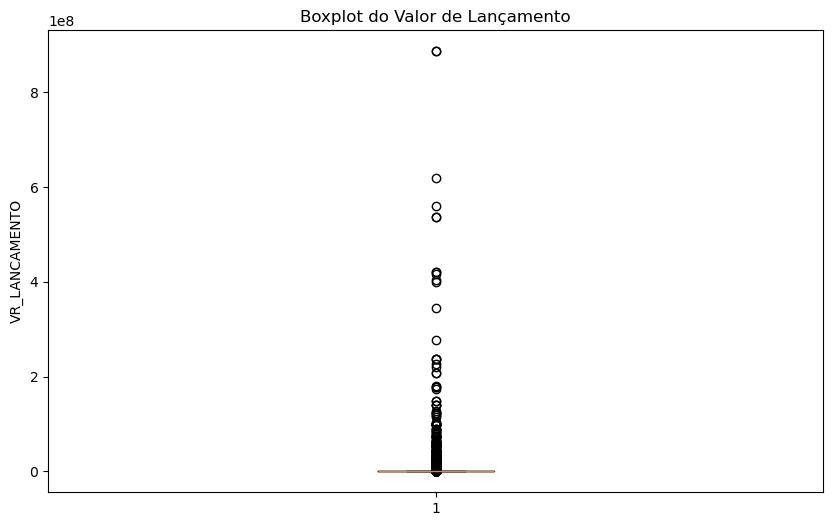

In [34]:
# Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(df_valor["VR_LANCAMENTO"], vert=True)
plt.title("Boxplot do Valor de Lançamento")
plt.ylabel("VR_LANCAMENTO")
plt.show()

In [20]:
# Criar uma variável logarítmica
# Para EDA, visualização, outliers e modelos, VR_LANCAMENTO bruto será dominado pelos extremos.
from pyspark.sql.functions import log1p

df_spark = df_spark.withColumn(
    "LOG_VR_LANCAMENTO",
    log1p(col("VR_LANCAMENTO"))
)

In [36]:
# Obter o resumo estatístico da variável logarítmica
resumo_estatistico = df_spark.select("LOG_VR_LANCAMENTO").describe().show()

+-------+-----------------+
|summary|LOG_VR_LANCAMENTO|
+-------+-----------------+
|  count|          1197344|
|   mean|5.591579030180678|
| stddev|2.952184302644433|
|    min|              0.0|
|    max|20.60317456431583|
+-------+-----------------+



In [37]:
# Selecionar a coluna "LOG_VR_LANCAMENTO" e convertê-la para Pandas
df_pandas_log = df_spark.select("LOG_VR_LANCAMENTO").toPandas()

df_valor_log = df_pandas_log.dropna()

In [38]:
# Mediana (2º Quartil)
mediana_log = df_valor_log['LOG_VR_LANCAMENTO'].median()
print(mediana_log)

5.5254529391317835


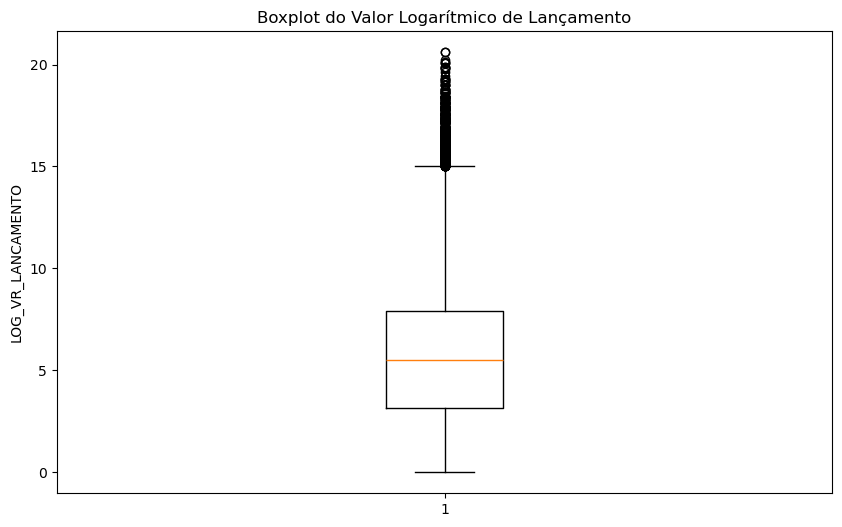

In [39]:
# Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(df_valor_log["LOG_VR_LANCAMENTO"], vert=True)
plt.title("Boxplot do Valor Logarítmico de Lançamento")
plt.ylabel("LOG_VR_LANCAMENTO")
plt.show()

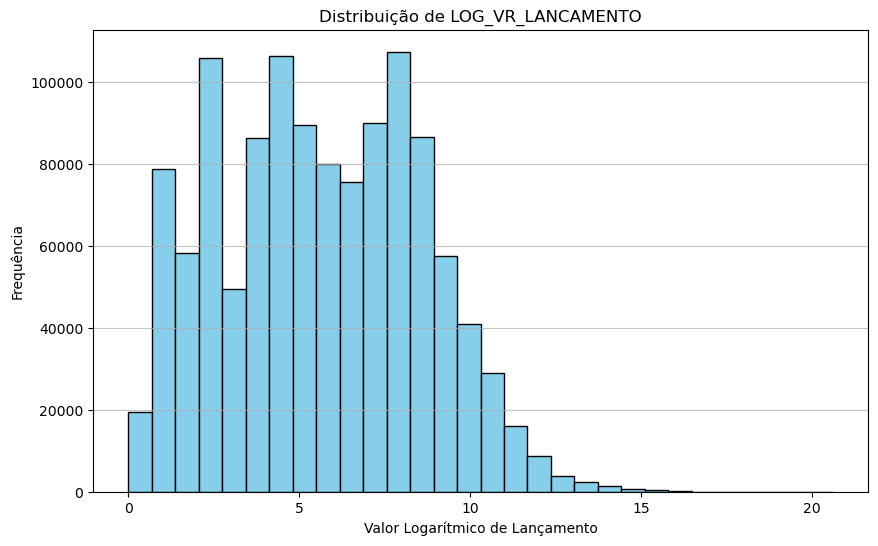

In [40]:
# Histograma
plt.figure(figsize=(10, 6))
plt.hist(df_valor_log["LOG_VR_LANCAMENTO"], bins=30, color='skyblue', edgecolor='black')

# Personalizar labels e título
plt.title("Distribuição de LOG_VR_LANCAMENTO")
plt.xlabel("Valor Logarítmico de Lançamento")
plt.ylabel("Frequência")

plt.grid(axis='y', alpha=0.75)
plt.show()

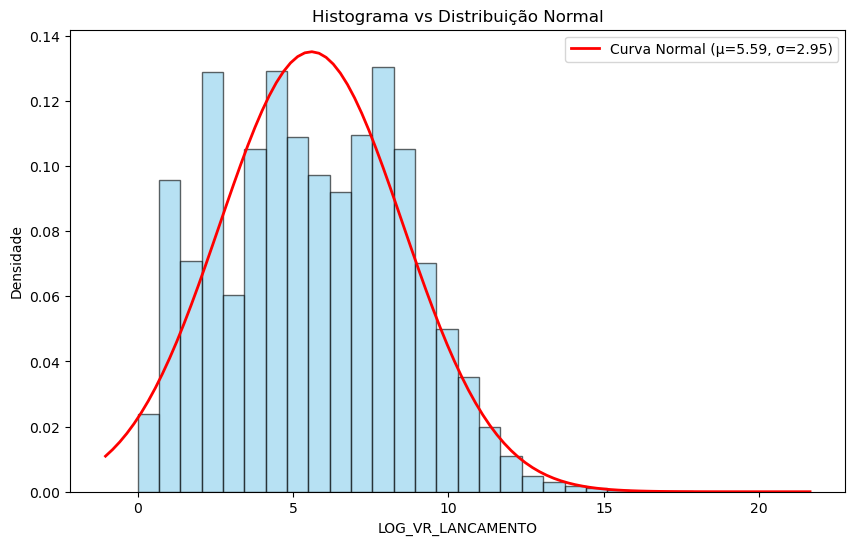

In [41]:
# Histograma vs Distribuição Normal
from scipy.stats import norm

# Calcular média (mu) e desvio padrão (std) para a curva teórica
mu, std = norm.fit(df_valor_log)

# 3. Criar o plot
plt.figure(figsize=(10, 6))

# Histograma normalizado (DENSITY=TRUE é obrigatório aqui)
plt.hist(df_valor_log["LOG_VR_LANCAMENTO"], bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')

# Criar o eixo X para a curva (do valor mínimo ao máximo dos dados)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std) # Calcula a densidade da normal para cada ponto de x

# 4. Plotar a curva gaussiana
plt.plot(x, p, 'r', linewidth=2, label=f'Curva Normal (μ={mu:.2f}, σ={std:.2f})')

plt.title("Histograma vs Distribuição Normal")
plt.xlabel("LOG_VR_LANCAMENTO")
plt.ylabel("Densidade")
plt.legend()
plt.show()

# ESTATÍSTICA DESCRITIVA

In [42]:
# Distribuição do número de lançamentos por tipo de operação
df_spark.groupBy('CD_TIPO_OPERACAO').count().orderBy(col('count').desc()).show()

+----------------+------+
|CD_TIPO_OPERACAO| count|
+----------------+------+
|             105|234390|
|             104|206518|
|             117|199649|
|             209|147420|
|             120|113631|
|             202| 56583|
|             213| 42454|
|             205| 42391|
|             999| 38748|
|             206| 22029|
|             112| 20067|
|             201| 18230|
|             101| 17979|
|             106| 11860|
|             217|  9195|
|             215|  7104|
|             114|  2525|
|             204|  2017|
|             203|   980|
|             214|   866|
+----------------+------+
only showing top 20 rows


In [43]:
# Distribuição de lançamentos por tipo de pessoa contraparte (Física/Jurídica). Obs.: "-1" indica pessoa não identificada
df_spark.groupBy('TP_PESSOA_CONTRAPARTE').count().show()

+---------------------+------+
|TP_PESSOA_CONTRAPARTE| count|
+---------------------+------+
|                   -1|138388|
|                    1|326530|
|                    2|732426|
+---------------------+------+



## Verificando a frequência de lançamentos por partido

In [44]:
# Partidos com mais operações
df_spark.groupBy('SG_PARTIDO', 'TP_LANCAMENTO').count().orderBy('count', ascending = False).show()

+------------+-------------+------+
|  SG_PARTIDO|TP_LANCAMENTO| count|
+------------+-------------+------+
|          PT|            D|143418|
|          PT|            C|112775|
|         MDB|            D| 81416|
|          PL|            D| 67746|
|          PP|            D| 64740|
|         PSB|            D| 42772|
|         PSD|            D| 40764|
|        PSDB|            D| 40726|
|       UNIÃO|            D| 39760|
|         PDT|            D| 39686|
|REPUBLICANOS|            D| 39009|
|         MDB|            C| 33568|
|        NOVO|            D| 32487|
|        PODE|            D| 31846|
|          PP|            C| 28329|
|        PSOL|            D| 26453|
|REPUBLICANOS|            C| 21084|
|         SDD|            D| 19462|
|     PC do B|            D| 19134|
|          UP|            C| 18736|
+------------+-------------+------+
only showing top 20 rows


## Valor Total por partido e tipo de lançamento

In [45]:
from pyspark.sql.functions import col, sum as _sum

# Agrupar por 'SG_PARTIDO' e 'TP_LANCAMENTO'; após, somar os valores de 'VR_LANCAMENTO'; e, por fim, ordenar
df_spark.groupBy('SG_PARTIDO', 'TP_LANCAMENTO') \
  .agg(_sum('VR_LANCAMENTO').alias('TOTAL_VR_LANCAMENTO')) \
  .orderBy(col('TOTAL_VR_LANCAMENTO').desc()) \
  .show()

+------------+-------------+--------------------+
|  SG_PARTIDO|TP_LANCAMENTO| TOTAL_VR_LANCAMENTO|
+------------+-------------+--------------------+
|          PL|            C|3.0106693688500023E9|
|          PL|            D| 3.008761227599996E9|
|       UNIÃO|            D|2.1600058136499996E9|
|       UNIÃO|            C|     2.15201532834E9|
|         PSD|            D| 1.696805481440002E9|
|         PSD|            C|1.6927458924799995E9|
|         MDB|            D| 1.573810337110032E9|
|         MDB|            C|1.5721723719399996E9|
|          PT|            D|1.5314866794200048E9|
|          PT|            C| 1.531044557749996E9|
|REPUBLICANOS|            C|1.3935769666500006E9|
|REPUBLICANOS|            D|     1.39175057087E9|
|          PP|            C|1.3508662995900004E9|
|          PP|            D|1.3501629709600046E9|
|        PODE|            D|1.1948993151400018E9|
|        PODE|            C|     1.19113617761E9|
|         PDT|            C| 7.528033278899996E8|


## Valor Total por partido e tipo de operação

In [46]:
# Agrupar por 'SG_PARTIDO' e 'DS_TIPO_OPERACAO'; após, somar os valores de 'VR_LANCAMENTO'; e, por fim, ordenar
df_spark.groupBy('SG_PARTIDO', 'DS_TIPO_OPERACAO') \
  .agg(_sum('VR_LANCAMENTO').alias('TOTAL_VR_LANCAMENTO')) \
  .orderBy(col('TOTAL_VR_LANCAMENTO').desc()) \
  .show()

+------------+--------------------+--------------------+
|  SG_PARTIDO|    DS_TIPO_OPERACAO| TOTAL_VR_LANCAMENTO|
+------------+--------------------+--------------------+
|          PL|TRANSFERÊNCIA ENT...|1.4988558293100002E9|
|       UNIÃO|TRANSFERÊNCIA ENT...|1.2486690398799999E9|
|          PL|RESGATE DE APLICAÇÃO|1.1865582553299997E9|
|          PT|TRANSFERÊNCIA ENT...|     1.18554901387E9|
|          PL|           APLICAÇÃO|1.1492725848100002E9|
|          PL| DEPÓSITOS ESPECIAIS|     1.07309974413E9|
|REPUBLICANOS|TRANSFERÊNCIA ENT...| 9.168189522599999E8|
|       UNIÃO|RESGATE DE APLICAÇÃO|      9.1633799326E8|
|       UNIÃO|           APLICAÇÃO|      9.1175904996E8|
|         PSD|TRANSFERÊNCIA ENT...| 8.620148492900002E8|
|          PP|TRANSFERÊNCIA ENT...| 8.033158866799998E8|
|          PT| DEPÓSITOS ESPECIAIS| 7.662821071700002E8|
|          PT|  LANÇAMENTO AVISADO| 7.625722328099946E8|
|         PSD|RESGATE DE APLICAÇÃO|       7.583788488E8|
|         PSD|           APLICA

## Valor Total por fonte do recurso

In [47]:
# Agrupar por 'DS_FONTE_RECURSO'; após, somar os valores de 'VR_LANCAMENTO'; e, por fim, ordenar
df_spark.groupBy('DS_FONTE_RECURSO') \
  .agg(_sum('VR_LANCAMENTO').alias('TOTAL_VR_LANCAMENTO')) \
  .orderBy(col('TOTAL_VR_LANCAMENTO').desc()) \
  .show()

+--------------------+--------------------+
|    DS_FONTE_RECURSO| TOTAL_VR_LANCAMENTO|
+--------------------+--------------------+
|Fundo Especial de...| 2.84357074533501E10|
|    Fundo Partidário| 6.409766739989911E9|
|     Outros Recursos|  6.52726145250001E8|
|Recursos Para Cam...|      2.7819800089E8|
|                NULL|1.1269391154999976E8|
|Fundo Partidário,...|          3168814.64|
|Fundo Partidário,...|          1438282.39|
|Recursos Para Cam...|           256587.12|
|Outros Recursos, ...|           228370.79|
|Fundo Partidário,...|  144119.19999999998|
|Outros Recursos, ...|           120933.08|
|Fundo Partidário,...|             1704.95|
|Fundo Partidário,...|               150.0|
+--------------------+--------------------+



## Análise das contrapartes

In [48]:
# Contrapartes com mais operações
df_spark.groupBy('NM_CONTRAPARTE').count().orderBy('count', ascending = False).show(20)

+--------------------+------+
|      NM_CONTRAPARTE| count|
+--------------------+------+
|BANCO DO BRASIL S.A.|228690|
|                NULL|121960|
|CAIXA ECONOMICA F...| 19718|
|         PT NACIONAL| 17083|
|TITULO - OUTRO BA...| 10557|
|SECRETARIA DO TES...|  9014|
|MINISTERIO DA ECO...|  7254|
|TITULO - OUTRO BA...|  4980|
|PARTIDO DOS TRABA...|  3947|
|     PROPRIO CLIENTE|  3174|
|      NAO LOCALIZADO|  2788|
|TITULO - OUTRO BA...|  2704|
|            CLARO SA|  2552|
|          Cef Matriz|  2352|
|BRADESCO/TARIFA B...|  1927|
|PARTIDO COMUNISTA...|  1840|
|TITULO - OUTRO BA...|  1800|
|BANCO DO ESTADO D...|  1776|
|ELIANE MARQUEZOLO...|  1717|
|        PARTIDO NOVO|  1557|
+--------------------+------+
only showing top 20 rows


In [49]:
# Agrupar por 'NM_CONTRAPARTE'; após, somar os valores de 'VR_LANCAMENTO'; e, por fim, ordenar
df_spark.groupBy('NM_CONTRAPARTE') \
  .agg(_sum('VR_LANCAMENTO').alias('TOTAL_VR_LANCAMENTO')) \
  .orderBy(col('TOTAL_VR_LANCAMENTO').desc()) \
  .show()

+--------------------+--------------------+
|      NM_CONTRAPARTE| TOTAL_VR_LANCAMENTO|
+--------------------+--------------------+
|                NULL|1.208868072032003...|
|TRIBUNAL SUPERIOR...|     4.95434037307E9|
|PARTIDO LIBERAL - PL|1.1450200591599998E9|
|FUNDO PARTID¿RIO ...|     1.04525732285E9|
|        UNIAO BRASIL| 9.152490175500002E8|
|REPUBLICANOS - BR...| 8.158131147899997E8|
|PARTIDO DOS TRABA...| 8.043042193299997E8|
|PARTIDO SOCIAL DE...|      6.0529353724E8|
|MOVIMENTO DEMOCRA...|      5.9181967656E8|
|             PODEMOS|      5.7492383588E8|
|PARTIDO DEMOCRATI...|3.7051727003999996E8|
|PROGRESSISTAS - B...|      3.4846937536E8|
|PARTIDO RENOVACAO...|      3.0911687798E8|
|PARTIDO DOS TRABA...|      2.4523258938E8|
|PARTIDO SOCIALISM...|2.2229463882000002E8|
|      NAO LOCALIZADO|      2.1209737336E8|
|PARTIDO SOCIALIST...|      1.7646828039E8|
|SOLIDARIEDADE - B...|      1.4801175323E8|
|FUNDO PARTIDARIO ...|1.4629931067000002E8|
|        PARTIDO NOVO|1.35883885

## Analisando operações por data

In [27]:
from pyspark.sql.functions import to_date

# Convertendo datas para o formato correto
df_spark = df_spark.withColumn('DT_LANCAMENTO', to_date(col('DT_LANCAMENTO'), 'dd/MM/yyyy'))

In [28]:
# Lançamentos ao longo do tempo
df_spark.groupBy(year('DT_LANCAMENTO'), month('DT_LANCAMENTO')).sum('VR_LANCAMENTO').orderBy('year(DT_LANCAMENTO)', 'month(DT_LANCAMENTO)').show()

+-------------------+--------------------+--------------------+
|year(DT_LANCAMENTO)|month(DT_LANCAMENTO)|  sum(VR_LANCAMENTO)|
+-------------------+--------------------+--------------------+
|               2023|                  12|          2607108.12|
|               2024|                   1| 5.648376287499996E8|
|               2024|                   2|4.4831441079999983E8|
|               2024|                   3| 4.802717925099998E8|
|               2024|                   4| 5.294947709100003E8|
|               2024|                   5| 6.184940931799988E8|
|               2024|                   6| 5.488414202200005E8|
|               2024|                   7| 6.181136988400002E8|
|               2024|                   8|2.135550445010011E10|
|               2024|                   9| 8.427260966109792E9|
|               2024|                  10| 1.321707546499997E9|
|               2024|                  11|      4.7307251612E8|
|               2024|                  1

## Bancos com mais operações

In [37]:
# Bancos mais usados
df_spark.groupBy('NM_BANCO').count().orderBy('count', ascending = False).show()

+--------------------+------+
|            NM_BANCO| count|
+--------------------+------+
|          BCO BRASIL|927587|
|BANCO DO ESTADO D...|121843|
|CAIXA ECONOMICA F...|105197|
|        BCO BRADESCO| 13110|
|            BANESTES|  7352|
|       BCO SANTANDER|  6252|
|BANCO DO ESTADO D...|  5692|
|  ITA? UNIBANCO S.A.|  3755|
|Banco do Estado d...|  3619|
|BANCO DE BRASILIA SA|  1795|
|BANCO DO NORDESTE...|   494|
|BANCO COOPERATIVO...|   365|
|BANCO DA AMAZONIA...|   283|
+--------------------+------+



In [38]:
bancos_pd = df_spark.groupBy('NM_BANCO').count().orderBy('count', ascending = False).toPandas()

bancos_pd

,NM_BANCO,count
0,BCO BRASIL,927587
1,BANCO DO ESTADO DO RIO GRANDE DO SUL,121843
2,CAIXA ECONOMICA FEDERAL,105197
3,BCO BRADESCO,13110
4,BANESTES,7352
5,BCO SANTANDER,6252
6,BANCO DO ESTADO DE SERGIPE S.A.,5692
7,ITA? UNIBANCO S.A.,3755
8,Banco do Estado do Par¿,3619
9,BANCO DE BRASILIA SA,1795


## Verificando a consistência dos dados

In [53]:
# Verificar se todos os lançamentos têm contrapartes válidas
df_spark.select([count(when(col('NR_CPF_CNPJ_CONTRAPARTE').isNull(), 'NR_CPF_CNPJ_CONTRAPARTE')).alias('NR_CPF_CNPJ_CONTRAPARTE'),
           count(when(col('VR_LANCAMENTO').isNull(), 'VR_LANCAMENTO')).alias('VR_LANCAMENTO')]).show()

+-----------------------+-------------+
|NR_CPF_CNPJ_CONTRAPARTE|VR_LANCAMENTO|
+-----------------------+-------------+
|                      0|            0|
+-----------------------+-------------+



# SELEÇÃO DE AMOSTRAS BASEADA NA DISTRIBUIÇÃO REAL (DATA-DRIVEN)

In [32]:
from pyspark.sql import functions as F

In [55]:
# Usar quantis aproximados
quantis = df_spark.approxQuantile(
    "VR_LANCAMENTO",
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999],
    0.001
)

quantis

[22.5, 250.0, 2711.0, 11000.0, 30000.0, 182658.92, 886839487.85]

In [56]:
# Com os quantis definidos (acima), definimos a faixa de valor
from pyspark.sql.functions import when

df_spark = df_spark.withColumn(
    "faixa_valor",
    when(col("VR_LANCAMENTO") <= 22.5, "E1")
    .when(col("VR_LANCAMENTO") <= 250, "E2")
    .when(col("VR_LANCAMENTO") <= 2700, "E3")
    .when(col("VR_LANCAMENTO") <= 11000, "E4")
    .when(col("VR_LANCAMENTO") <= 30000, "E5")
    .when(col("VR_LANCAMENTO") <= 177500, "E6")
    .when(col("VR_LANCAMENTO") <= 1000000, "E7")
    .otherwise("E8")
)

In [57]:
# Estrato final
from pyspark.sql.functions import concat_ws

df_spark = df_spark.withColumn(
    "estrato",
    concat_ws("_",
        col("faixa_valor"),
        col("CD_TIPO_OPERACAO"),
        col("SG_PARTIDO")
    )
)

## 1. Parâmetros gerais

In [58]:
N = df_spark.count()
n_target = 10000
frac_aas = n_target / N
R = 30  # número de repetições Monte Carlo

## 2. Contagem populacional por estrato: N_h

In [59]:
pop_strata = (
    df_spark
    .groupBy("estrato")
    .agg(F.count("*").alias("N_h"))
    .withColumn("W_h", F.col("N_h") / F.lit(N))
)

## 3. Frações da amostra estratificada desproporcional

Ajuste conforme desenho amostral

In [60]:
counts_collect = pop_strata.select("estrato").collect()

fractions_disprop = {}

for row in counts_collect:
    estrato = row["estrato"]

    if estrato.startswith("E8"):
        fractions_disprop[estrato] = 0.20
    elif estrato.startswith("E7"):
        fractions_disprop[estrato] = 0.10
    elif estrato.startswith("E6"):
        fractions_disprop[estrato] = 0.05
    else:
        fractions_disprop[estrato] = 0.005

## 4. Funções de amostragem

In [61]:
# Amostragem AAS
def sample_aas(df, frac, seed=SEED):
    return df.sample(withReplacement=False, fraction=frac, seed=seed)

# Amostragem estratificada
def sample_stratified(df, fractions, seed=SEED):
    return df.sampleBy("estrato", fractions=fractions, seed=seed)

## 5. Métricas AAS ou STRAT sem ponderação

In [62]:
def metrics_unweighted(df, method, rep):
    stats = df.selectExpr(
        "avg(VR_LANCAMENTO) as mean",
        "stddev_samp(VR_LANCAMENTO) as std",
        "count(*) as n"
    ).collect()[0]

    mean = float(stats["mean"])
    std = float(stats["std"]) if stats["std"] is not None else 0.0
    n = int(stats["n"])

    se = std / (n ** 0.5) if n > 0 else None
    z = 1.96

    qs = df.approxQuantile(
        "VR_LANCAMENTO",
        [0.90, 0.95, 0.99],
        0.001
    )

    return {
        "method": method,
        "rep": rep,
        "n": n,
        "mean": mean,
        "std": std,
        "se": se,
        "ci_low": mean - z * se if se is not None else None,
        "ci_high": mean + z * se if se is not None else None,
        "q90": qs[0],
        "q95": qs[1],
        "q99": qs[2],
    }

## 6. Métricas STRAT ponderada

Estimador correto da média:
ybar_st = soma_h W_h * ybar_h

In [63]:
def metrics_strat_weighted(sample_df, pop_strata, method, rep):

    sample_strata = (
        sample_df
        .groupBy("estrato")
        .agg(
            F.count("*").alias("n_h_sample"),
            F.avg("VR_LANCAMENTO").alias("ybar_h"),
            F.var_samp("VR_LANCAMENTO").alias("s2_h")
        )
    )

    pop_strata_clean = (
        pop_strata
        .select(
            F.col("estrato"),
            F.col("N_h").alias("N_h_pop"),
            F.col("W_h").alias("W_h_pop")
        )
    )

    joined = (
        sample_strata
        .join(pop_strata_clean, on="estrato", how="inner")
        .withColumn(
            "weighted_mean_component",
            F.col("W_h_pop") * F.col("ybar_h")
        )
        .withColumn(
            "var_component",
            (F.col("W_h_pop") ** 2) *
            (F.col("s2_h") / F.col("n_h_sample"))
        )
    )

    result = joined.agg(
        F.sum("weighted_mean_component").alias("mean"),
        F.sum("var_component").alias("var_mean")
    ).collect()[0]

    mean = float(result["mean"])
    var_mean = float(result["var_mean"]) if result["var_mean"] is not None else 0.0
    se = var_mean ** 0.5
    z = 1.96

    n_total = sample_df.count()

    qs = sample_df.approxQuantile(
        "VR_LANCAMENTO",
        [0.90, 0.95, 0.99],
        0.001
    )

    return {
        "method": method,
        "rep": rep,
        "n": n_total,
        "mean": mean,
        "std": None,
        "se": se,
        "ci_low": mean - z * se,
        "ci_high": mean + z * se,
        "q90": qs[0],
        "q95": qs[1],
        "q99": qs[2],
    }

## 7. Monte Carlo:

AAS vs STRAT sem peso vs STRAT ponderada

In [64]:
# Monte Carlo (seed progressivo)
def monte_carlo_seed(i):
    return SEED + i

In [65]:
results = []

for i in range(R):

    seed_i = monte_carlo_seed(i)

    # AAS
    df_aas_i = sample_aas(df_spark, frac_aas, seed=seed_i)
    results.append(
        metrics_unweighted(df_aas_i, method="AAS", rep=i)
    )

    # Estratificada desproporcional
    df_str_i = sample_stratified(df_spark, fractions_disprop, seed=seed_i)

    # STRAT sem ponderação
    results.append(
        metrics_unweighted(df_str_i, method="STRAT_unweighted", rep=i)
    )

    # STRAT ponderada
    results.append(
        metrics_strat_weighted(
            df_str_i,
            pop_strata=pop_strata,
            method="STRAT_weighted",
            rep=i
        )
    )


res_df = pd.DataFrame(results)

## 8. Comparações principais

In [66]:
res_df["ci_width"] = res_df["ci_high"] - res_df["ci_low"]

comparacao_media = (
    res_df
    .groupby("method")["mean"]
    .agg(["mean", "std", "min", "max"])
)

comparacao_ic = (
    res_df
    .groupby("method")["ci_width"]
    .agg(["mean", "std", "min", "max"])
)

comparacao_quantis = (
    res_df
    .groupby("method")[["q90", "q95", "q99"]]
    .mean()
)

print("Comparação das médias:")
display(comparacao_media)

print("Comparação da largura dos ICs:")
display(comparacao_ic)

print("Comparação dos quantis superiores:")
display(comparacao_quantis)

Comparação das médias:


,mean,std,min,max
method,,,,
AAS,28203.204162,15091.838459,14581.604768,80840.138452
STRAT_unweighted,613185.678261,71750.655677,478112.354001,756824.441257
STRAT_weighted,29112.346760,3218.760237,23136.649478,36103.718349


Comparação da largura dos ICs:


,mean,std,min,max
method,,,,
AAS,41469.820406,47268.067109,7385.316927,219446.631345
STRAT_unweighted,405918.604232,93683.043151,240236.173677,624657.435220
STRAT_weighted,15569.493498,4933.778882,7379.063791,28815.215354


Comparação dos quantis superiores:


,q90,q95,q99
method,,,
AAS,11088.361333,3.012019e+04,1.752107e+05
STRAT_unweighted,363233.789000,1.262157e+06,6.544715e+06
STRAT_weighted,363233.789000,1.262157e+06,6.544715e+06


# DETECÇÃO DE OUTLIERS

In [21]:
# Quantis da variável "VR_LANCAMENTO"
df_spark.approxQuantile(
    "VR_LANCAMENTO",
    [0.99, 0.995, 0.999],
    0.001
)

[182658.92, 400000.0, 886839487.85]

In [22]:
# Contagem de zeros
df_spark.filter(col("VR_LANCAMENTO") == 0).count()

15

In [23]:
# Quantis da variável "LOG_VR_LANCAMENTO" (adicional)
df_spark.approxQuantile(
    "LOG_VR_LANCAMENTO",
    [0.25, 0.5, 0.75, 0.9, 0.99],
    0.001
)

[3.157000421150113,
 5.5254529391317835,
 7.905441649060286,
 9.305741456739435,
 12.115381342273386]

## Critério híbrido: quantis + log

In [24]:
# Criar a categoria de outlier
df_spark = df_spark.withColumn(
    "categoria_outlier",
    when(col("VR_LANCAMENTO") <= 30000, "normal")
    .when(col("VR_LANCAMENTO") <= 182658.92, "intermediario")
    .otherwise("extremo")
)

In [71]:
# Função para calcular proporções
def proporcao_outliers(df, nome_metodo):
    total = df.count()
    
    return (
        df.groupBy("categoria_outlier")
          .agg(F.count("*").alias("n"))
          .withColumn("proporcao", F.col("n") / F.lit(total))
          .withColumn("method", F.lit(nome_metodo))
    )

In [72]:
# Comparar AAS vs STRAT_unweighted
# Usamos uma repetição específica (seed=42)
df_aas = sample_aas(df_spark, frac_aas, seed=SEED)

df_strat = sample_stratified(
    df_spark,
    fractions=fractions_disprop,
    seed=SEED
)

# Agora calculamos
prop_aas = proporcao_outliers(df_aas, "AAS")
prop_strat = proporcao_outliers(df_strat, "STRAT_unweighted")

comparacao_outliers = prop_aas.unionByName(prop_strat)

comparacao_outliers.orderBy("method", "categoria_outlier").show()

+-----------------+----+--------------------+----------------+
|categoria_outlier|   n|           proporcao|          method|
+-----------------+----+--------------------+----------------+
|          extremo| 102|0.010035419126328217|             AAS|
|    intermediario| 406| 0.03994490358126722|             AAS|
|           normal|9656|  0.9500196772924046|             AAS|
|          extremo|1514| 0.15866694613288618|STRAT_unweighted|
|    intermediario|2291| 0.24009641584573466|STRAT_unweighted|
|           normal|5737|  0.6012366380213792|STRAT_unweighted|
+-----------------+----+--------------------+----------------+



In [73]:
# Proporção populacional de referência
prop_pop = proporcao_outliers(df_spark, "POPULACAO")

prop_pop.orderBy("categoria_outlier").show()

+-----------------+-------+--------------------+---------+
|categoria_outlier|      n|           proporcao|   method|
+-----------------+-------+--------------------+---------+
|          extremo|  12418|0.010371288451773259|POPULACAO|
|    intermediario|  45268| 0.03780701285511933|POPULACAO|
|           normal|1139658|  0.9518216986931074|POPULACAO|
+-----------------+-------+--------------------+---------+



In [74]:
# Agora, usaremos pesos por estrato para estimar a proporção populacional de cada categoria
def proporcao_outliers_weighted(sample_df, pop_strata, nome_metodo):
    # total amostral por estrato
    n_por_estrato = (
        sample_df
        .groupBy("estrato")
        .agg(F.count("*").alias("n_h_sample"))
    )

    # contagem por estrato e categoria
    cat_por_estrato = (
        sample_df
        .groupBy("estrato", "categoria_outlier")
        .agg(F.count("*").alias("n_ch"))
    )

    # proporção da categoria dentro de cada estrato
    prop_cat_estrato = (
        cat_por_estrato
        .join(n_por_estrato, on="estrato", how="inner")
        .withColumn("p_ch", F.col("n_ch") / F.col("n_h_sample"))
    )

    pop_strata_clean = (
        pop_strata
        .select(
            F.col("estrato"),
            F.col("W_h").alias("W_h_pop")
        )
    )

    # estimador estratificado ponderado da proporção
    prop_weighted = (
        prop_cat_estrato
        .join(pop_strata_clean, on="estrato", how="inner")
        .withColumn("weighted_component", F.col("W_h_pop") * F.col("p_ch"))
        .groupBy("categoria_outlier")
        .agg(F.sum("weighted_component").alias("proporcao"))
        .withColumn("method", F.lit(nome_metodo))
    )

    return prop_weighted

In [75]:
# Agora comparamos os três
df_aas = sample_aas(df_spark, frac_aas, seed=SEED)

df_strat = sample_stratified(
    df_spark,
    fractions=fractions_disprop,
    seed=SEED
)

prop_pop = proporcao_outliers(df_spark, "POPULACAO")
prop_aas = proporcao_outliers(df_aas, "AAS")
prop_strat_unw = proporcao_outliers(df_strat, "STRAT_unweighted")
prop_strat_w = proporcao_outliers_weighted(df_strat, pop_strata, "STRAT_weighted")

comparacao_outliers = (
    prop_pop
    .select("method", "categoria_outlier", "proporcao")
    .unionByName(prop_aas.select("method", "categoria_outlier", "proporcao"))
    .unionByName(prop_strat_unw.select("method", "categoria_outlier", "proporcao"))
    .unionByName(prop_strat_w.select("method", "categoria_outlier", "proporcao"))
)

comparacao_outliers.orderBy("categoria_outlier", "method").show(truncate=False)

+----------------+-----------------+--------------------+
|method          |categoria_outlier|proporcao           |
+----------------+-----------------+--------------------+
|AAS             |extremo          |0.010035419126328217|
|POPULACAO       |extremo          |0.010371288451773259|
|STRAT_unweighted|extremo          |0.15866694613288618 |
|STRAT_weighted  |extremo          |0.009984736911306564|
|AAS             |intermediario    |0.03994490358126722 |
|POPULACAO       |intermediario    |0.03780701285511933 |
|STRAT_unweighted|intermediario    |0.24009641584573466 |
|STRAT_weighted  |intermediario    |0.037085278055152555|
|AAS             |normal           |0.9500196772924046  |
|POPULACAO       |normal           |0.9518216986931074  |
|STRAT_unweighted|normal           |0.6012366380213792  |
|STRAT_weighted  |normal           |0.8982297485100361  |
+----------------+-----------------+--------------------+



In [76]:
# Para uma melhor visualização em Pandas
comparacao_pd = comparacao_outliers.toPandas()

comparacao_pivot = comparacao_pd.pivot(
    index="categoria_outlier",
    columns="method",
    values="proporcao"
)

comparacao_pivot

method,AAS,POPULACAO,STRAT_unweighted,STRAT_weighted
categoria_outlier,,,,
extremo,0.010035,0.010371,0.158667,0.009985
intermediario,0.039945,0.037807,0.240096,0.037085
normal,0.950020,0.951822,0.601237,0.898230


In [77]:
# Erro Absoluto por método
erro_df = comparacao_pivot.copy()

for col in ["AAS", "STRAT_unweighted", "STRAT_weighted"]:
    erro_df[col + "_erro"] = np.abs(erro_df[col] - erro_df["POPULACAO"])
    
erro_df

method,AAS,POPULACAO,STRAT_unweighted,STRAT_weighted,AAS_erro,STRAT_unweighted_erro,STRAT_weighted_erro
categoria_outlier,,,,,,,
extremo,0.010035,0.010371,0.158667,0.009985,0.000336,0.148296,0.000387
intermediario,0.039945,0.037807,0.240096,0.037085,0.002138,0.202289,0.000722
normal,0.950020,0.951822,0.601237,0.898230,0.001802,0.350585,0.053592


In [78]:
# Erro Médio Total
erro_total = erro_df[[
    "AAS_erro",
    "STRAT_unweighted_erro",
    "STRAT_weighted_erro"
]].mean()

erro_total

method
AAS_erro                 0.001425
STRAT_unweighted_erro    0.233723
STRAT_weighted_erro      0.018233
dtype: float64

In [79]:
# Divergência de Distribuição
# Jensen-Shannon
from scipy.spatial.distance import jensenshannon

def js_divergence(p, q):
    return jensenshannon(p, q)

p_pop = comparacao_pivot["POPULACAO"].values

for metodo in ["AAS", "STRAT_unweighted", "STRAT_weighted"]:
    q = comparacao_pivot[metodo].values
    print(metodo, js_divergence(p_pop, q))

AAS 0.004062856151065086
STRAT_unweighted 0.31637755484232183
STRAT_weighted 0.0027134016597647054


## Impacto Financeiro Global

In [80]:
impacto_financeiro = (
    df_spark
    .groupBy("categoria_outlier")
    .agg(
        F.count("*").alias("n"),
        F.sum("VR_LANCAMENTO").alias("valor_total")
    )
)

total_geral = df_spark.agg(
    F.sum("VR_LANCAMENTO").alias("total")
).collect()[0]["total"]

impacto_financeiro = impacto_financeiro.withColumn(
    "proporcao_registros",
    F.col("n") / F.lit(df_spark.count())
).withColumn(
    "proporcao_valor",
    F.col("valor_total") / F.lit(total_geral)
)

impacto_financeiro.orderBy("proporcao_valor", ascending=False).show(truncate=False)

+-----------------+-------+---------------------+--------------------+-------------------+
|categoria_outlier|n      |valor_total          |proporcao_registros |proporcao_valor    |
+-----------------+-------+---------------------+--------------------+-------------------+
|extremo          |12418  |3.0063103474629986E10|0.010371288451773259|0.8375418054469174 |
|intermediario    |45268  |3.267937083859999E9  |0.03780701285511933 |0.09104295993967486|
|normal           |1139658|2.5634106547100606E9 |0.9518216986931074  |0.07141523461340357|
+-----------------+-------+---------------------+--------------------+-------------------+



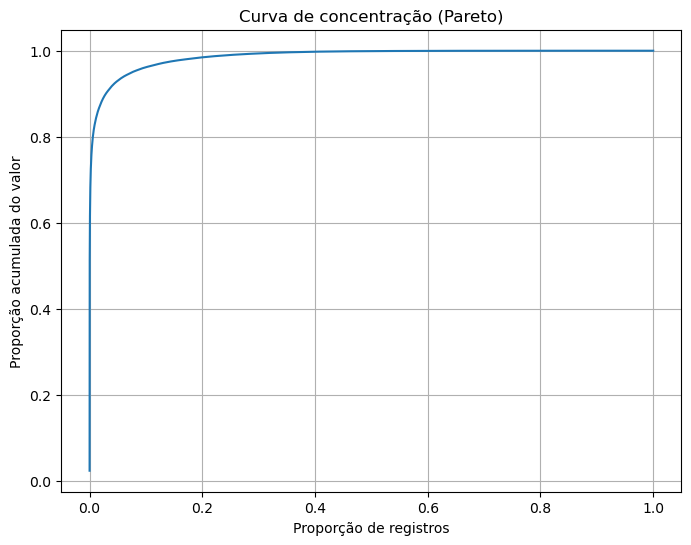

In [81]:
# Curva De Concentração (PARETO)
df_pandas = df_spark.select("VR_LANCAMENTO").toPandas()

df_pandas = df_pandas.sort_values("VR_LANCAMENTO", ascending=False)

df_pandas["cum_valor"] = df_pandas["VR_LANCAMENTO"].cumsum()
df_pandas["cum_perc"] = df_pandas["cum_valor"] / df_pandas["VR_LANCAMENTO"].sum()

df_pandas["rank_perc"] = np.arange(1, len(df_pandas)+1) / len(df_pandas)

# Visualização
plt.figure(figsize=(8,6))
plt.plot(df_pandas["rank_perc"], df_pandas["cum_perc"])
plt.xlabel("Proporção de registros")
plt.ylabel("Proporção acumulada do valor")
plt.title("Curva de concentração (Pareto)")
plt.grid(True)
plt.show()

In [82]:
# Métrica Formal (GINI)
def gini(array):
    array = np.sort(array)
    n = len(array)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * array) / (n * np.sum(array))) - (n + 1) / n

gini_index = gini(df_pandas["VR_LANCAMENTO"].values)
gini_index

np.float64(0.9735457384569755)

# DETECÇÃO DE OUTLIERS POR MEIO DE ML: CLUSTERIZAÇÃO (K-MEANS EM ESCALA LOG)

In [25]:
# Base e feature
df_cluster = df_spark.select(
    "VR_LANCAMENTO",
    "LOG_VR_LANCAMENTO",
    "categoria_outlier"
).toPandas()

X = df_cluster[["LOG_VR_LANCAMENTO"]].values

In [27]:
# Escolha K usando uma amostra
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# amostra para escolha de K
df_cluster_sample = (
    df_spark
    .select("VR_LANCAMENTO", "LOG_VR_LANCAMENTO", "categoria_outlier")
    .sample(withReplacement=False, fraction=0.05, seed=SEED)
    .toPandas()
)

X_sample = df_cluster_sample[["LOG_VR_LANCAMENTO"]].values

inertias = []
silhouettes = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_sample)
    
    inertias.append(km.inertia_)
    
    silhouettes.append(
        silhouette_score(X_sample, labels, sample_size=10000, random_state=SEED)
    )

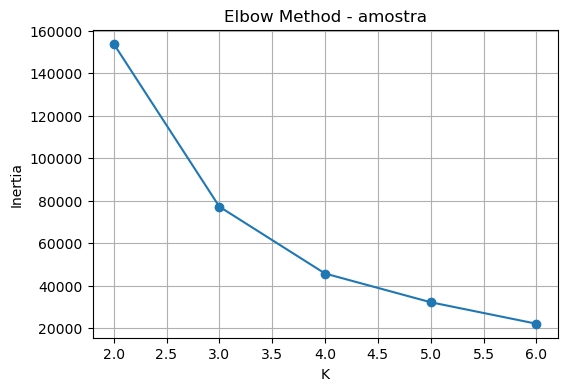

In [28]:
# Gráfico Elbow Method
plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method - amostra")
plt.grid(True)
plt.show()

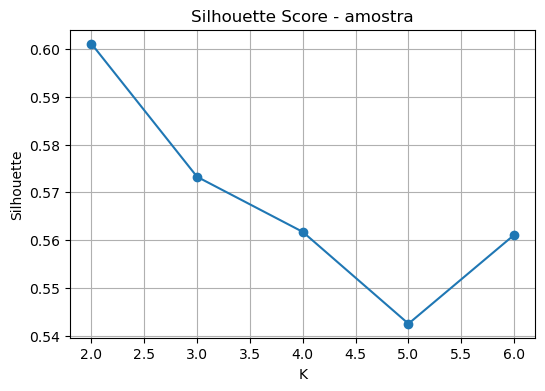

In [29]:
# Gráfico Silhouette Score
plt.figure(figsize=(6,4))
plt.plot(list(K_range), silhouettes, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.title("Silhouette Score - amostra")
plt.grid(True)
plt.show()

In [87]:
# Aplicação do K-Means na base completa em relação à variável (LOG_VR_LANCAMENTO), utilizando o PySpark
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

def kmeans_model(df, k=3, seed=SEED):
    return KMeans(
        k=k,
        seed=seed,
        featuresCol="features",
        predictionCol="cluster"
    )

assembler = VectorAssembler(
    inputCols=["LOG_VR_LANCAMENTO"],
    outputCol="features"
)

df_kmeans = assembler.transform(df_spark)

kmeans = kmeans_model(df_kmeans, k=3, seed=SEED)

model = kmeans.fit(df_kmeans)

df_clustered = model.transform(df_kmeans)

cluster_stats = (
    df_clustered
    .groupBy("cluster")
    .agg(F.mean("VR_LANCAMENTO").alias("media"))
    .orderBy("media")  # ordena do menor para o maior
)

cluster_stats.show()

+-------+-----------------+
|cluster|            media|
+-------+-----------------+
|      1| 10.9907217173382|
|      0|347.3782893344329|
|      2|89009.51721603605|
+-------+-----------------+



In [88]:
# Criar mapeamento ordenado
# coletar clusters ordenados
clusters_ordenados = [row["cluster"] for row in cluster_stats.collect()]

mapping = {
    clusters_ordenados[i]: i
    for i in range(len(clusters_ordenados))
}

In [89]:
# Aplicar nova ordenação
from pyspark.sql.functions import create_map, lit
from itertools import chain

# transformar dict em expressão Spark
mapping_expr = create_map(
    [lit(x) for x in chain(*mapping.items())]
)

df_clustered = df_clustered.withColumn(
    "cluster_ord",
    mapping_expr[F.col("cluster")]
)

In [90]:
# Criar rótulo semântico
df_clustered = df_clustered.withColumn(
    "cluster_label",
    F.when(F.col("cluster_ord") == 0, "normal")
     .when(F.col("cluster_ord") == 1, "intermediario")
     .when(F.col("cluster_ord") == 2, "extremo")
)

In [91]:
df_clustered.groupBy("cluster_label").agg(
    F.count("*").alias("n"),
    F.mean("VR_LANCAMENTO").alias("media")
).orderBy("media").show()

+-------------+------+-----------------+
|cluster_label|     n|            media|
+-------------+------+-----------------+
|       normal|355527| 10.9907217173382|
|intermediario|440314|347.3782893344329|
|      extremo|401503|89009.51721603605|
+-------------+------+-----------------+



In [92]:
# Resumo dos clusters
resumo_clusters = (
    df_clustered
    .groupBy("cluster_label")
    .agg(
        F.count("*").alias("n"),
        F.mean("VR_LANCAMENTO").alias("media"),
        F.expr("percentile_approx(VR_LANCAMENTO, 0.5)").alias("mediana"),
        F.min("VR_LANCAMENTO").alias("minimo"),
        F.expr("percentile_approx(VR_LANCAMENTO, 0.90)").alias("q90"),
        F.expr("percentile_approx(VR_LANCAMENTO, 0.95)").alias("q95"),
        F.expr("percentile_approx(VR_LANCAMENTO, 0.99)").alias("q99"),
        F.max("VR_LANCAMENTO").alias("maximo")
    )
    .orderBy("media")
)

resumo_clusters.show(truncate=False)

+-------------+------+-----------------+-------+------+-------+---------+---------+--------------+
|cluster_label|n     |media            |mediana|minimo|q90    |q95      |q99      |maximo        |
+-------------+------+-----------------+-------+------+-------+---------+---------+--------------+
|normal       |355527|10.9907217173382 |9.0    |0.0   |30.0   |30.7     |40.0     |40.81         |
|intermediario|440314|347.3782893344329|200.0  |40.82 |978.0  |1000.0   |1226.95  |1290.9        |
|extremo      |401503|89009.51721603605|5000.0 |1291.0|50000.0|100973.77|684451.44|8.8683948785E8|
+-------------+------+-----------------+-------+------+-------+---------+---------+--------------+



In [93]:
# Impacto Financeiro por Cluster
impacto_cluster = (
    df_clustered
    .groupBy("cluster_label")
    .agg(
        F.count("*").alias("n"),
        F.sum("VR_LANCAMENTO").alias("valor_total")
    )
)

total_valor = df_clustered.agg(
    F.sum("VR_LANCAMENTO")
).collect()[0][0]

impacto_cluster = impacto_cluster.withColumn(
    "prop_registros",
    F.col("n") / F.lit(df_clustered.count())
).withColumn(
    "prop_valor",
    F.col("valor_total") / F.lit(total_valor)
)

impacto_cluster_pd = impacto_cluster.orderBy("prop_valor", ascending=False).toPandas()

print(impacto_cluster_pd)

   cluster_label       n   valor_total  prop_registros  prop_valor
0        extremo  401503  3.573759e+10        0.335328    0.995630
1  intermediario  440314  1.529555e+08        0.367742    0.004261
2         normal  355527  3.907498e+06        0.296930    0.000109


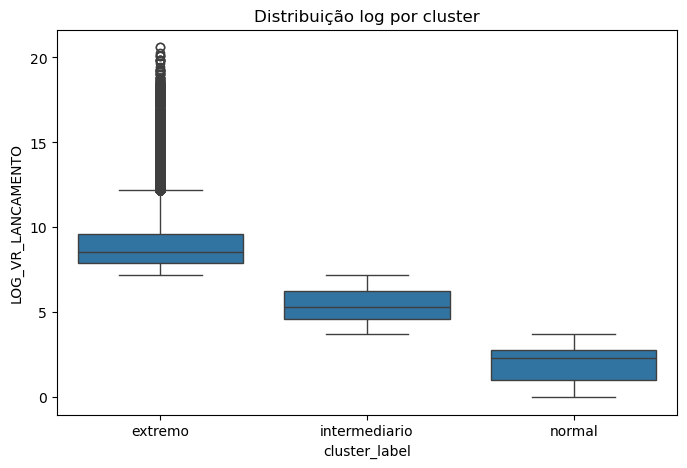

In [94]:
# Visualização gráfica
# Boxplot em escala log
df_plot = df_clustered.select(
    "cluster_label", "LOG_VR_LANCAMENTO"
).toPandas().sort_values("cluster_label")

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_plot,
    x="cluster_label",
    y="LOG_VR_LANCAMENTO"
)
plt.title("Distribuição log por cluster")
plt.show()

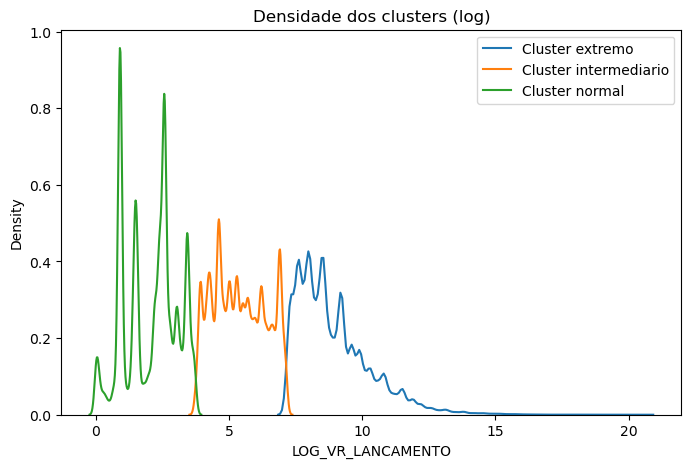

In [95]:
# Densidade
plt.figure(figsize=(8,5))

for c in sorted(df_plot["cluster_label"].unique()):
    subset = df_plot[df_plot["cluster_label"] == c]
    sns.kdeplot(
        subset["LOG_VR_LANCAMENTO"],
        label=f"Cluster {c}"
    )

plt.legend()
plt.title("Densidade dos clusters (log)")
plt.show()

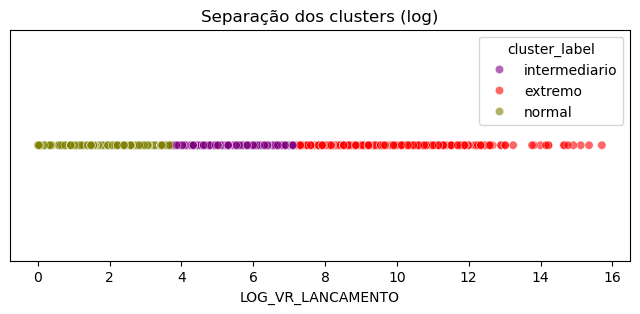

In [96]:
# Scatter simples (1D expandido)
plt.figure(figsize=(8,3))

sns.scatterplot(
    data=df_plot.sample(5000),
    x="LOG_VR_LANCAMENTO",
    y=[0]*5000,
    hue="cluster_label",
    palette="brg",
    alpha=0.6
)

plt.yticks([])
plt.title("Separação dos clusters (log)")
plt.show()

# ANÁLISE DE GRAFOS

In [97]:
# 1. Base: somente extremos, C/D e PF/PJ
df_grafo = (
    df_spark
    .filter(F.col("categoria_outlier") == "extremo")
    .filter(F.col("TP_LANCAMENTO").isin(["C", "D"]))
    .filter(F.col("TP_PESSOA_CONTRAPARTE").isin(["1", "2"]))
    .select(
        "SG_PARTIDO",
        "TP_LANCAMENTO",
        "VR_LANCAMENTO",
        "NR_CPF_CNPJ_CONTRAPARTE",
        "NM_CONTRAPARTE",
        "TP_PESSOA_CONTRAPARTE"
    )
)

In [98]:
# 2. Agregar para reduzir o grafo
df_edges = (
    df_grafo
    .groupBy(
        "SG_PARTIDO",
        "TP_LANCAMENTO",
        "NR_CPF_CNPJ_CONTRAPARTE",
        "NM_CONTRAPARTE",
        "TP_PESSOA_CONTRAPARTE"
    )
    .agg(
        F.sum("VR_LANCAMENTO").alias("valor_total"),
        F.count("*").alias("n_transacoes")
    )
    .orderBy(F.col("valor_total").desc())
)

TOP_N = 160
edges_pd = df_edges.limit(TOP_N).toPandas()

In [99]:
import networkx as nx

G = nx.Graph()

def contraparte_label(row):
    tipo = "PF" if row["TP_PESSOA_CONTRAPARTE"] == "1" else "PJ"
    return f"{tipo}_{row['NR_CPF_CNPJ_CONTRAPARTE']}"

for i, row in edges_pd.iterrows():
    partido = f"PARTIDO: {row['SG_PARTIDO']}"
    contraparte = contraparte_label(row)
    valor_node = f"{row['TP_LANCAMENTO']}: R$ {row['valor_total']:,.0f}"

    valor = float(row["valor_total"])
    tp = row["TP_LANCAMENTO"]

    # Nós
    G.add_node(partido, tipo="partido", label=row["SG_PARTIDO"], valor=valor)
    G.add_node(
        valor_node,
        tipo="valor",
        label="Crédito" if tp == "C" else "Débito",
        valor=valor,
        tp_lancamento=tp
    )
    G.add_node(
        contraparte,
        tipo="contraparte",
        label=contraparte,
        valor=valor
    )

    # Arestas
    G.add_edge(partido, valor_node, weight=valor)
    G.add_edge(valor_node, contraparte, weight=valor)

In [100]:
# 3. Atributos visuais
import builtins

node_colors = []
node_sizes = []
labels = {}

# apenas valores dos nós de transação
valores = [
    data["valor"]
    for n, data in G.nodes(data=True)
    if data["tipo"] == "valor"
]

max_valor = builtins.max(valores) if valores else 1

for n, data in G.nodes(data=True):

    tipo = data["tipo"]

    # PARTIDOS
    if tipo == "partido":
        node_colors.append("#FFF7AE")
        node_sizes.append(900)
        labels[n] = data["label"]

    # NÓS DE VALOR (CRÉDITO / DÉBITO)
    elif tipo == "valor":

        # tamanho proporcional ao valor
        size = 100 + 10000 * (
            (data["valor"] / max_valor) ** 0.3
        )
        node_sizes.append(size)

        # cor por tipo de lançamento
        if data["tp_lancamento"] == "C":
            node_colors.append("#5BE36D")  # crédito
        else:
            node_colors.append("#E85D5D")  # débito

        labels[n] = ""  # sem rótulo

    # CONTRAPARTES
    else:
        node_colors.append("#9FD3E6")
        node_sizes.append(350)

        # PF ou PJ
        if data.get("tp_pessoa") == "1":
            labels[n] = "PF"
        else:
            labels[n] = "PJ"

In [101]:
# Criar Dicionários De Rótulos
labels_partido = {}
labels_contraparte = {}

for n, data in G.nodes(data=True):
    if data["tipo"] == "partido":
        labels_partido[n] = data["label"]

    elif data["tipo"] == "contraparte":
        if data.get("tp_pessoa") == "1":
            labels_contraparte[n] = "PF"
        else:
            labels_contraparte[n] = "PJ"

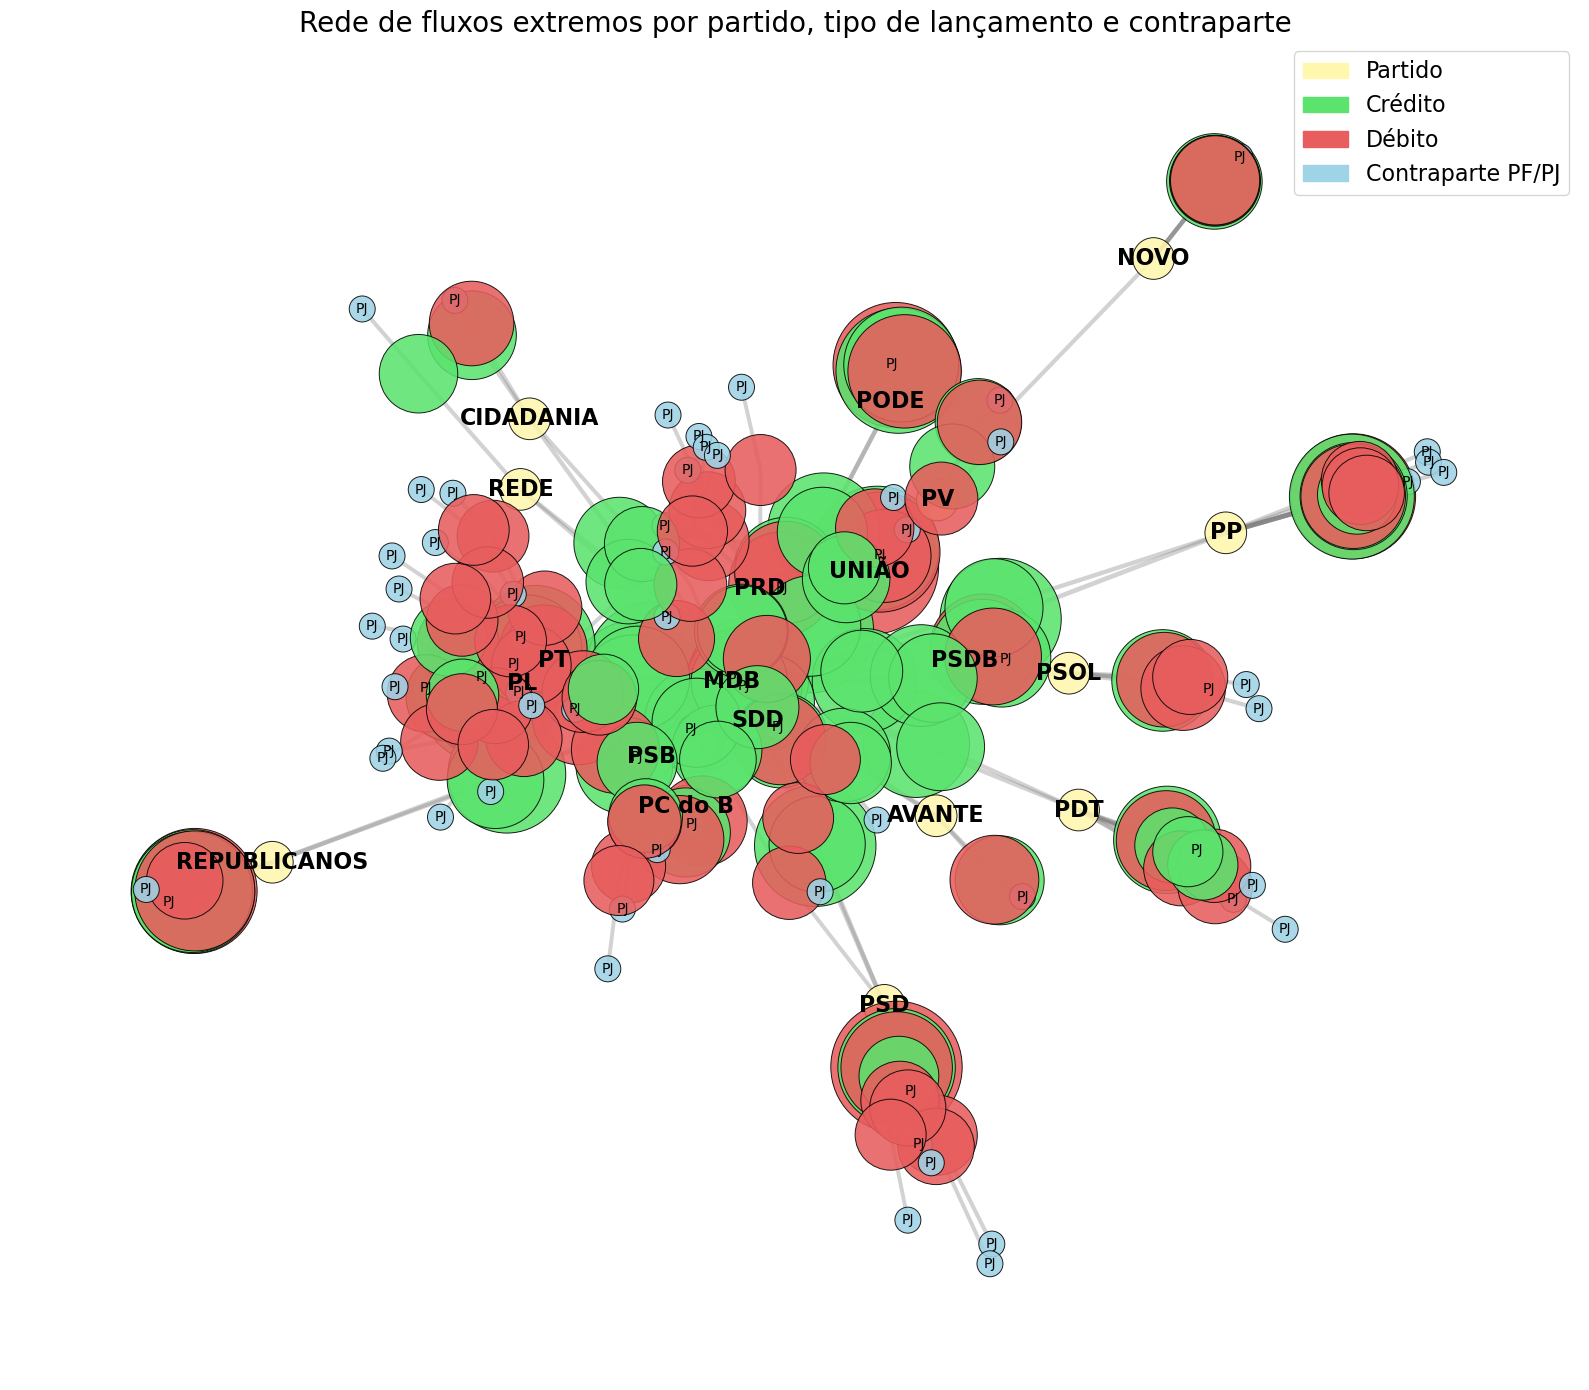

In [106]:
# 4. Layout e visualização

plt.figure(figsize=(16, 14))

pos = nx.spring_layout(
    G,
    k=0.55,
    seed=SEED,
    iterations=100
)

edge_weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
edge_widths = 0.5 + 3 * (np.log1p(edge_weights) / np.log1p(edge_weights.max()))

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.35,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.88,
    linewidths=0.7,
    edgecolors="black"
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels_partido,
    font_size=16,
    font_weight="bold"
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels_contraparte,
    font_size=10
)

# Legenda
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="#FFF7AE", label="Partido"),
    mpatches.Patch(color="#5BE36D", label="Crédito"),
    mpatches.Patch(color="#E85D5D", label="Débito"),
    mpatches.Patch(color="#9FD3E6", label="Contraparte PF/PJ"),
]

plt.legend(handles=legend_items, loc="upper right", fontsize=16)
plt.title("Rede de fluxos extremos por partido, tipo de lançamento e contraparte", fontsize=20)
plt.axis("off")
plt.tight_layout()
plt.show()

## Análise realizada a partir das 10 principais legendas

In [107]:
from pyspark.sql import functions as F

# Base filtrada
df_grafo_base = (
    df_spark
    .filter(F.col("categoria_outlier") == "extremo")
    .filter(F.col("TP_LANCAMENTO").isin(["C", "D"]))
    .filter(F.col("TP_PESSOA_CONTRAPARTE").isin(["1", "2"]))
)

# Partidos que possuem tanto crédito quanto débito
partidos_cd = (
    df_grafo_base
    .groupBy("SG_PARTIDO")
    .agg(
        F.countDistinct("TP_LANCAMENTO").alias("n_tipos_lancamento"),
        F.sum("VR_LANCAMENTO").alias("valor_total")
    )
    .filter(F.col("n_tipos_lancamento") == 2)
    .orderBy(F.col("valor_total").desc())
    .limit(10)
)

# Lista dos 10 partidos
top_10_partidos = [row["SG_PARTIDO"] for row in partidos_cd.collect()]

top_10_partidos

['PL',
 'UNIÃO',
 'REPUBLICANOS',
 'PT',
 'PSD',
 'PP',
 'PODE',
 'MDB',
 'PDT',
 'PSDB']

In [108]:
df_grafo = (
    df_grafo_base
    .filter(F.col("SG_PARTIDO").isin(top_10_partidos))
    .select(
        "SG_PARTIDO",
        "TP_LANCAMENTO",
        "VR_LANCAMENTO",
        "NR_CPF_CNPJ_CONTRAPARTE",
        "NM_CONTRAPARTE",
        "TP_PESSOA_CONTRAPARTE"
    )
)

In [109]:
# 2. Agregar para reduzir o grafo
df_edges = (
    df_grafo
    .groupBy(
        "SG_PARTIDO",
        "TP_LANCAMENTO",
        "NR_CPF_CNPJ_CONTRAPARTE",
        "NM_CONTRAPARTE",
        "TP_PESSOA_CONTRAPARTE"
    )
    .agg(
        F.sum("VR_LANCAMENTO").alias("valor_total"),
        F.count("*").alias("n_transacoes")
    )
    .orderBy(F.col("valor_total").desc())
)

TOP_N = 60
edges_pd = df_edges.limit(TOP_N).toPandas()

In [110]:
import networkx as nx

G = nx.Graph()

def contraparte_label(row):
    tipo = "PF" if row["TP_PESSOA_CONTRAPARTE"] == "1" else "PJ"
    return f"{tipo}_{row['NR_CPF_CNPJ_CONTRAPARTE']}"

for i, row in edges_pd.iterrows():
    partido = f"PARTIDO: {row['SG_PARTIDO']}"
    contraparte = contraparte_label(row)
    valor_node = f"{row['TP_LANCAMENTO']}: R$ {row['valor_total']:,.0f}"

    valor = float(row["valor_total"])
    tp = row["TP_LANCAMENTO"]

    # Nós
    G.add_node(partido, tipo="partido", label=row["SG_PARTIDO"], valor=valor)
    G.add_node(
        valor_node,
        tipo="valor",
        label="Crédito" if tp == "C" else "Débito",
        valor=valor,
        tp_lancamento=tp
    )
    G.add_node(
        contraparte,
        tipo="contraparte",
        label=contraparte,
        valor=valor
    )

    # Arestas
    G.add_edge(partido, valor_node, weight=valor)
    G.add_edge(valor_node, contraparte, weight=valor)

In [111]:
# 3. Atributos visuais
import builtins

node_colors = []
node_sizes = []
labels = {}

# apenas valores dos nós de transação
valores = [
    data["valor"]
    for n, data in G.nodes(data=True)
    if data["tipo"] == "valor"
]

max_valor = builtins.max(valores) if valores else 1

for n, data in G.nodes(data=True):

    tipo = data["tipo"]

    # PARTIDOS
    if tipo == "partido":
        node_colors.append("#FFF7AE")
        node_sizes.append(900)
        labels[n] = data["label"]

    # NÓS DE VALOR (CRÉDITO / DÉBITO)
    elif tipo == "valor":

        # tamanho proporcional ao valor
        size = 100 + 8000 * (
            (data["valor"] / max_valor) ** 0.3
        )
        node_sizes.append(size)

        # cor por tipo de lançamento
        if data["tp_lancamento"] == "C":
            node_colors.append("#5BE36D")  # crédito
        else:
            node_colors.append("#E85D5D")  # débito

        labels[n] = ""  # sem rótulo

    # CONTRAPARTES
    else:
        node_colors.append("#9FD3E6")
        node_sizes.append(350)

        # PF ou PJ
        if data.get("tp_pessoa") == "1":
            labels[n] = "PF"
        else:
            labels[n] = "PJ"

In [112]:
# Criar Dicionários De Rótulos
labels_partido = {}
labels_contraparte = {}

for n, data in G.nodes(data=True):
    if data["tipo"] == "partido":
        labels_partido[n] = data["label"]

    elif data["tipo"] == "contraparte":
        if data.get("tp_pessoa") == "1":
            labels_contraparte[n] = "PF"
        else:
            labels_contraparte[n] = "PJ"

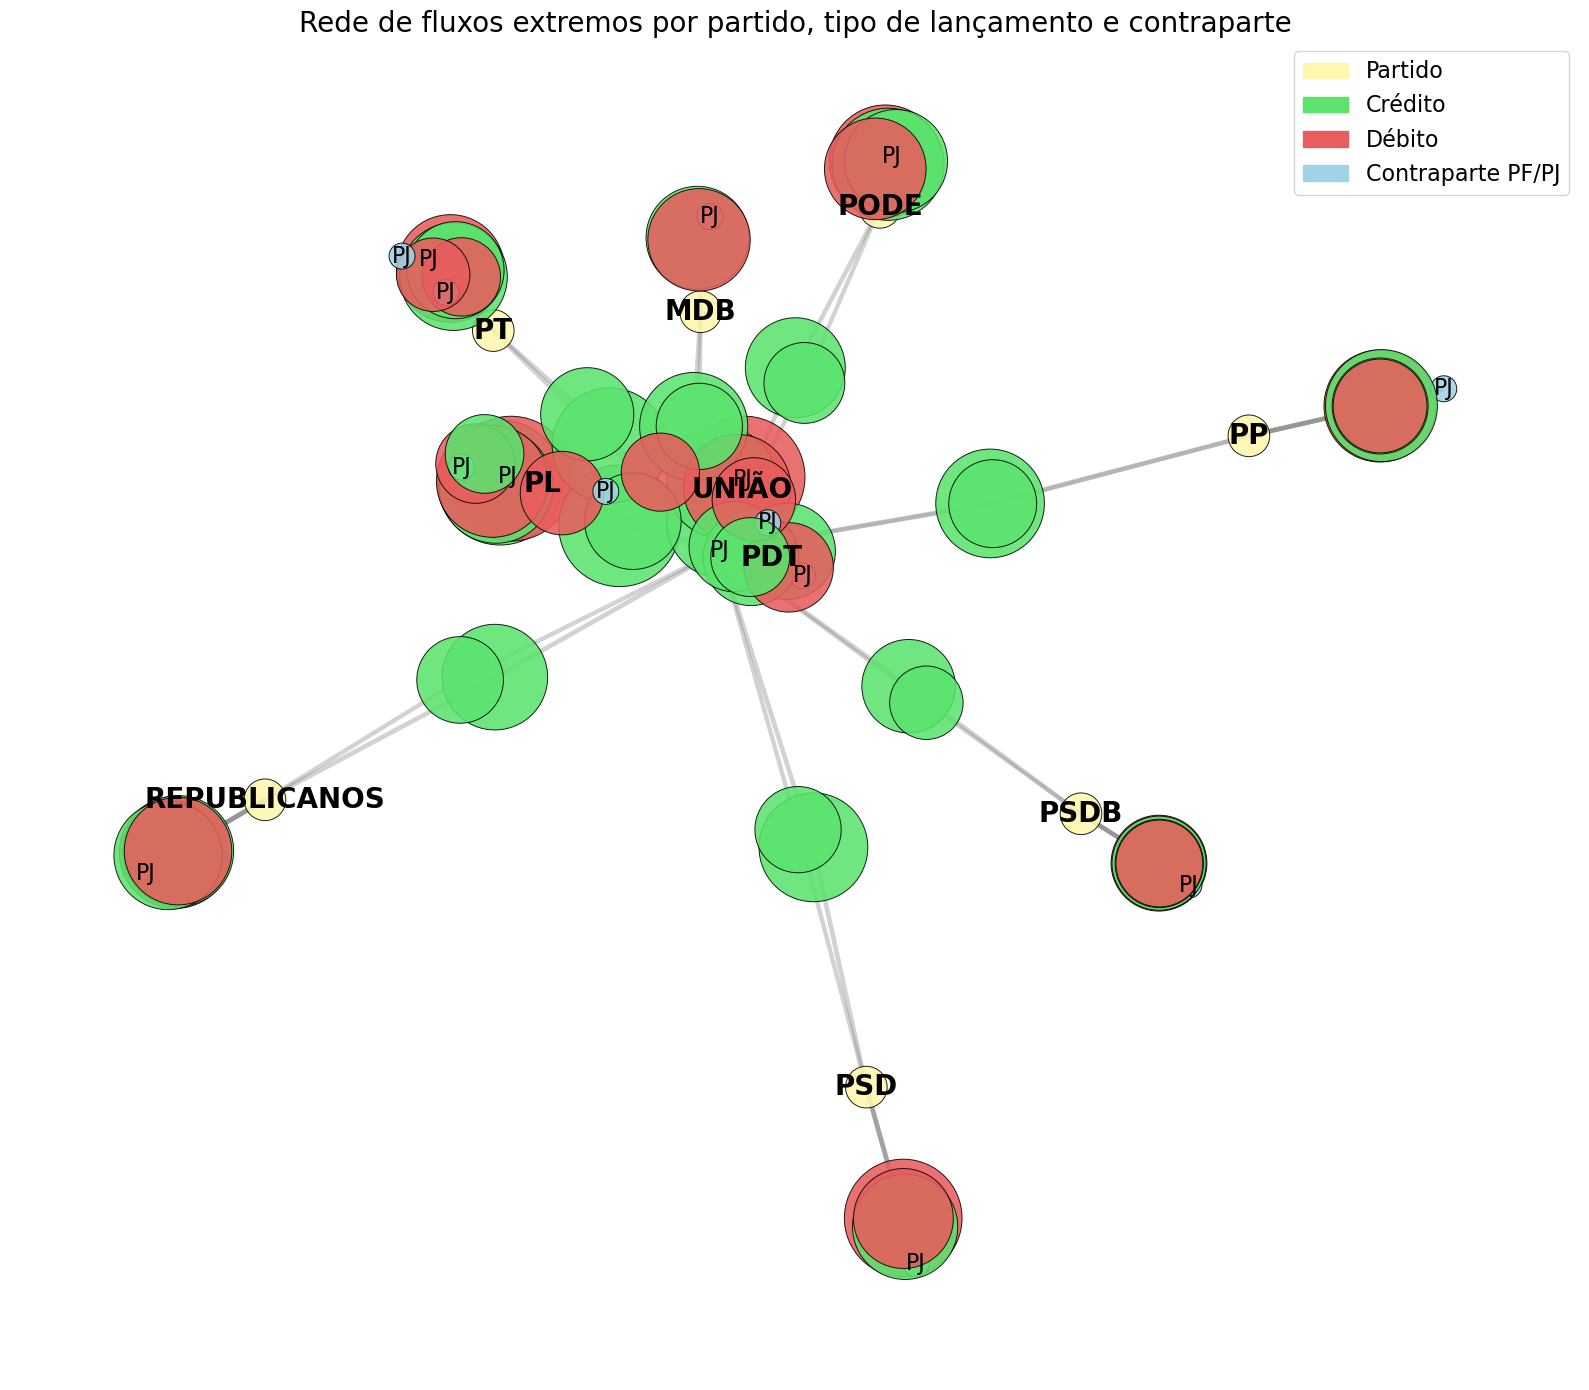

In [115]:
# 4. Layout e visualização

plt.figure(figsize=(16, 14))

pos = nx.spring_layout(
    G,
    k=0.55,
    seed=SEED,
    iterations=100
)

edge_weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
edge_widths = 0.5 + 3 * (np.log1p(edge_weights) / np.log1p(edge_weights.max()))

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.35,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.88,
    linewidths=0.7,
    edgecolors="black"
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels_partido,
    font_size=20,
    font_weight="bold"
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels_contraparte,
    font_size=16
)

# Legenda
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="#FFF7AE", label="Partido"),
    mpatches.Patch(color="#5BE36D", label="Crédito"),
    mpatches.Patch(color="#E85D5D", label="Débito"),
    mpatches.Patch(color="#9FD3E6", label="Contraparte PF/PJ"),
]

plt.legend(handles=legend_items, loc="upper right", fontsize=16)
plt.title("Rede de fluxos extremos por partido, tipo de lançamento e contraparte", fontsize=20)
plt.axis("off")
plt.tight_layout()
plt.show()

In [116]:
# Encerra a sessão Spark
spark_session.stop()

# Fim